<a href="https://colab.research.google.com/github/zaidan-khairiazhar/machine-learning-python/blob/main/ML_Method_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
print("--- 1. MEMUAT DATASET ---")
# Menggunakan Pima Indians Diabetes Dataset
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
try:
    df = pd.read_csv(url)
    print("Dataset berhasil dimuat dari URL.")
except Exception as e:
    print(f"Gagal memuat dataset: {e}")
    exit()

--- 1. MEMUAT DATASET ---
Dataset berhasil dimuat dari URL.


In [3]:
print("\n--- 2. EXPLORATORY DATA ANALYSIS (EDA) ---")

print("\n[5 Data Teratas]")
print(df.head())

print("\n[Info Dataset]")
print(df.info())

print("\n[Pengecekan Missing Value]")
print(df.isnull().sum())

print("\n[Statistik Deskriptif]")
print(df.describe())


--- 2. EXPLORATORY DATA ANALYSIS (EDA) ---

[5 Data Teratas]
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

[Info Dataset]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregna

In [4]:
print("\n--- 3. PREPROCESSING ---")

# Memisahkan Fitur (X) dan Target (y)
# Target kolom di dataset ini adalah 'Outcome' (0 = Tidak Diabetes, 1 = Diabetes)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisasi (Scaling)
scaler = StandardScaler()
# Fit pada training set, transform pada training dan test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil dibagi dan distandarisasi.")
print(f"Jumlah Data Train: {X_train.shape[0]}")
print(f"Jumlah Data Test: {X_test.shape[0]}")


--- 3. PREPROCESSING ---
Data berhasil dibagi dan distandarisasi.
Jumlah Data Train: 614
Jumlah Data Test: 154


In [5]:
print("\n--- 4. TRAINING MODEL ---")

# Model 1: Support Vector Machine (SVM) dengan Kernel RBF
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
print("Model SVM (Kernel RBF) berhasil dilatih.")

# Model 2: K-Nearest Neighbors (KNN) dengan k=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print("Model KNN (k=5) berhasil dilatih.")


--- 4. TRAINING MODEL ---
Model SVM (Kernel RBF) berhasil dilatih.
Model KNN (k=5) berhasil dilatih.



--- 5. EVALUASI DAN VISUALISASI ---

>>> Classification Report: SVM
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


>>> Classification Report: KNN
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154



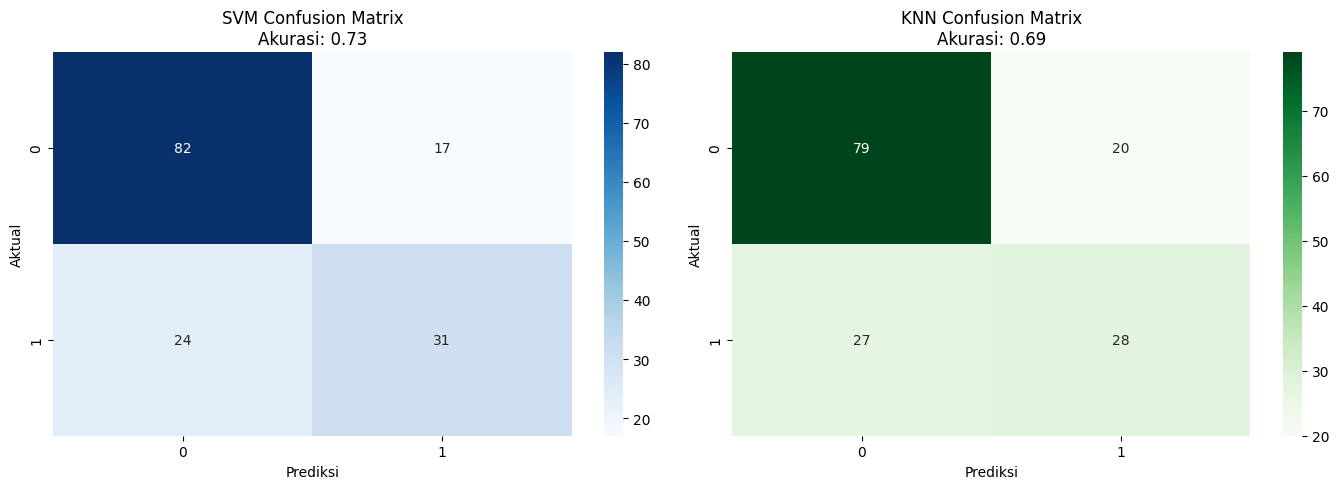

In [6]:
print("\n--- 5. EVALUASI DAN VISUALISASI ---")

# Prediksi
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

# Menghitung Metrik
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

# Laporan Klasifikasi
print("\n>>> Classification Report: SVM")
print(classification_report(y_test, y_pred_svm))

print("\n>>> Classification Report: KNN")
print(classification_report(y_test, y_pred_knn))

# Visualisasi Confusion Matrix Side-by-Side
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'SVM Confusion Matrix\nAkurasi: {acc_svm:.2f}')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Plot KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'KNN Confusion Matrix\nAkurasi: {acc_knn:.2f}')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [7]:
print("\n--- 6. KESIMPULAN PERBANDINGAN MODEL ---")

print(f"Akurasi SVM : {acc_svm:.4f} | F1-Score SVM : {f1_svm:.4f}")
print(f"Akurasi KNN : {acc_knn:.4f} | F1-Score KNN : {f1_knn:.4f}")

print("\nAnalisis Singkat:")
if f1_svm > f1_knn:
    winner = "SVM"
    reason = "SVM dengan kernel RBF mampu menangani batas keputusan non-linear dengan lebih baik dan cenderung lebih robust terhadap dimensi data dibandingkan KNN pada dataset ini."
elif f1_knn > f1_svm:
    winner = "KNN"
    reason = "KNN berhasil menangkap pola lokal dengan baik. Struktur data mungkin memiliki cluster-cluster yang bertetangga dekat yang lebih mudah dikenali oleh algoritma berbasis jarak langsung."
else:
    winner = "Seimbang"
    reason = "Kedua model memberikan performa yang identik."

print(f"Model Terbaik: **{winner}**")
print(f"Alasan: {reason}")
print("Catatan: Performa SVM sangat terbantu oleh proses Scaling (StandardScaler) yang telah dilakukan.")


--- 6. KESIMPULAN PERBANDINGAN MODEL ---
Akurasi SVM : 0.7338 | F1-Score SVM : 0.6019
Akurasi KNN : 0.6948 | F1-Score KNN : 0.5437

Analisis Singkat:
Model Terbaik: **SVM**
Alasan: SVM dengan kernel RBF mampu menangani batas keputusan non-linear dengan lebih baik dan cenderung lebih robust terhadap dimensi data dibandingkan KNN pada dataset ini.
Catatan: Performa SVM sangat terbantu oleh proses Scaling (StandardScaler) yang telah dilakukan.
